# n_jobs scaling — TSCGlue transforms and heads

How the transforms and classifier heads that `TSCGlueEnhancedV4` actually uses scale with `n_jobs ∈ {1, 2, 4, 8, 16}`, on the FordB training set (3636 × 500). Every transform is built through `tscglue.models.get_feature_transformer` and every head with the exact parameters from `MODELS_DICTIONARY`, so these are the objects the stack really runs.

**Transforms.** V4's model pool needs eight representations: `multirocket`, `hydra`, `quant`, `rdst`, `rstsf-random`, `weasel`, `mantis`, `chronos2`.

* The five scalable ones — `multirocket`, `hydra`, `rdst`, `rstsf-random`, `weasel` — take `n_jobs` and are the point of the plot.
* `quant` is included and will come out **flat**: `get_feature_transformer` builds it as `QUANTTransformer()`, which has no `n_jobs` parameter at all. The flat line is the correct result, not a measurement artefact.
* `mantis` and `chronos2` are **excluded**. They are foundation-model embeddings parameterised by `device`, not `n_jobs`, so there is no CPU-thread axis to sweep, and they would pull model weights.

**Heads.** `ridgecv` and `extratrees` on MultiRocket features, matching `multirockethydra-p-ridgecv` (`RidgeClassifierCVDecisionProba`, whose `n_jobs` is a BLAS thread budget applied with `threadpool_limits`) and `multirockethydra-etc` (`ExtraTreesClassifier`), including each one's scaler from `MODELS_DICTIONARY` — `StandardScaler` for ridge, none for the trees.

Each timed run is preceded by a short warm-up so numba compilation is not charged to the first measurement. WEASEL at `n_jobs=1` on the full training set is the slow one; set `N_TRAIN` to subsample if you want a quicker pass.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler

from tscglue.models import get_feature_transformer
from tscglue.tabular import RidgeClassifierCVDecisionProba
from tscglue.utils import load_dataset

DATASET = "FordB"
SEED = 153153030
GRID = [1, 2, 4, 8, 16]
N_TRAIN = None

X_train, y_train, _, _ = load_dataset(DATASET)
X = X_train if N_TRAIN is None else X_train[:N_TRAIN]
y = y_train if N_TRAIN is None else y_train[:N_TRAIN]
print(X.shape)

(3636, 1, 500)


## Transforms

In [2]:
TRANSFORMS = ["multirocket", "hydra", "rdst", "rstsf-random", "weasel", "quant"]

rows = []
for name in TRANSFORMS:
    for n_jobs in GRID:
        get_feature_transformer(name, seed=SEED, n_jobs=n_jobs).fit_transform(X[:60], y[:60])
        t0 = time.perf_counter()
        Xt = get_feature_transformer(name, seed=SEED, n_jobs=n_jobs).fit_transform(X, y)
        seconds = time.perf_counter() - t0
        rows.append({"what": name, "n_jobs": n_jobs, "seconds": seconds})
        print(f"{name:<14} n_jobs={n_jobs:<3} {seconds:8.1f}s  {Xt.shape}", flush=True)

multirocket    n_jobs=1       35.2s  (3636, 49728)


multirocket    n_jobs=2       18.1s  (3636, 49728)


multirocket    n_jobs=4        9.6s  (3636, 49728)


multirocket    n_jobs=8        5.3s  (3636, 49728)


multirocket    n_jobs=16       3.2s  (3636, 49728)


...

quant          n_jobs=1        0.6s  (3636, 4469)


quant          n_jobs=2        0.6s  (3636, 4469)


quant          n_jobs=4        0.6s  (3636, 4469)


quant          n_jobs=8        0.6s  (3636, 4469)


quant          n_jobs=16       0.6s  (3636, 4469)


## Heads on MultiRocket features

In [3]:
Xmr = get_feature_transformer("multirocket", seed=SEED, n_jobs=max(GRID)).fit_transform(X, y)
Xmr_scaled = StandardScaler().fit_transform(Xmr)
print(Xmr.shape)


def make_head(kind, n_jobs):
    if kind == "ridgecv":
        return RidgeClassifierCVDecisionProba(alphas=np.logspace(-3, 3, 10), n_jobs=n_jobs)
    return ExtraTreesClassifier(
        n_estimators=200,
        criterion="entropy",
        max_features="sqrt",
        random_state=SEED,
        n_jobs=n_jobs,
    )


for kind, data in [("ridgecv", Xmr_scaled), ("extratrees", Xmr)]:
    for n_jobs in GRID:
        make_head(kind, n_jobs).fit(data[:60], y[:60])
        t0 = time.perf_counter()
        make_head(kind, n_jobs).fit(data, y)
        seconds = time.perf_counter() - t0
        rows.append({"what": kind, "n_jobs": n_jobs, "seconds": seconds})
        print(f"{kind:<14} n_jobs={n_jobs:<3} {seconds:8.1f}s", flush=True)

results = pd.DataFrame(rows)
base = results[results["n_jobs"] == 1].set_index("what")["seconds"]
results["speed-up"] = base[results["what"]].to_numpy() / results["seconds"]
results.round(2)

(3636, 49728)


ridgecv        n_jobs=1       32.5s


ridgecv        n_jobs=2       18.0s


ridgecv        n_jobs=4       10.7s


ridgecv        n_jobs=8        7.3s


...

extratrees     n_jobs=2        8.2s


extratrees     n_jobs=4        4.4s


extratrees     n_jobs=8        2.6s


extratrees     n_jobs=16       1.9s


,what,n_jobs,seconds,speed-up
0,multirocket,1,35.23,1.00
1,multirocket,2,18.15,1.94
2,multirocket,4,9.61,3.67
3,multirocket,8,5.34,6.60
4,multirocket,16,3.23,10.91
5,hydra,1,38.26,1.00
6,hydra,2,21.46,1.78
7,hydra,4,11.64,3.29
8,hydra,8,6.85,5.59
9,hydra,16,5.72,6.69


## Graph

In [4]:
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
SERIES = "#2a78d6"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # one blue per n_jobs, light -> dark
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11,
    "axes.titleweight": "bold", "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRIDLINE, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "legend.frameon": False, "figure.dpi": 110,
})

HEADS = {"ridgecv", "extratrees"}
order = results[results["n_jobs"] == max(GRID)].sort_values("speed-up")["what"].tolist()
label = {w: f"{w}  (head)" if w in HEADS else w for w in order}

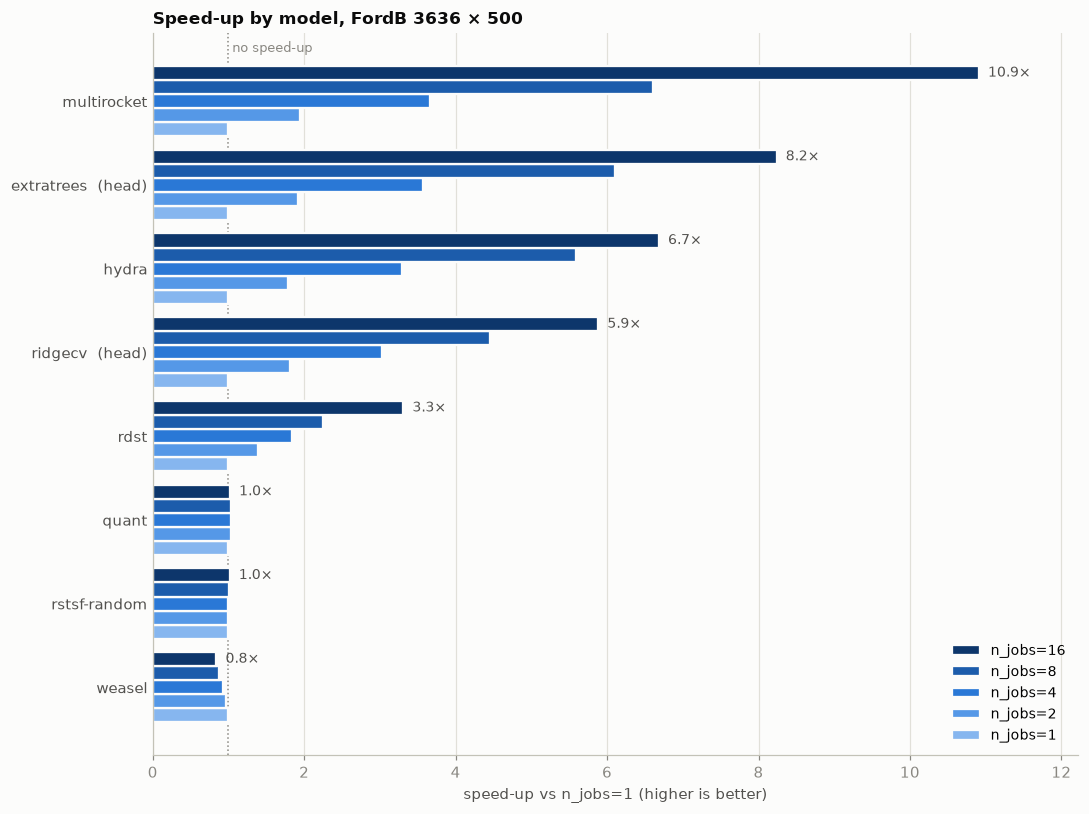

In [5]:
# Speed-up per model

fig, ax = plt.subplots(figsize=(10, 7.5))
band, bar_h = 0.84, 0.84 / len(GRID)
for i, n_jobs in enumerate(GRID):
    d = results[results["n_jobs"] == n_jobs].set_index("what").loc[order]
    y = np.arange(len(order)) - band / 2 + (i + 0.5) * bar_h
    ax.barh(y, d["speed-up"], height=bar_h, color=RAMP[i], edgecolor=SURFACE, linewidth=1.5,
            label=f"n_jobs={n_jobs}", zorder=2)
    if n_jobs == max(GRID):
        for yy, v in zip(y, d["speed-up"]):
            ax.text(v + 0.12, yy, f"{v:.1f}×", va="center", fontsize=9, color=INK2)

ax.axvline(1, color=MUTED, lw=1, ls=":", zorder=1)
ax.text(1.05, len(order) - 0.45, "no speed-up", fontsize=8.5, color=MUTED, va="bottom")
ax.set_yticks(np.arange(len(order)), [label[w] for w in order], color=INK2)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.set_xlabel("speed-up vs n_jobs=1 (higher is better)")
ax.set_xlim(0, results["speed-up"].max() * 1.12)
ax.set_title(f"Speed-up by model, {DATASET} {X.shape[0]} × {X.shape[-1]}", loc="left")
ax.legend(loc="lower right", ncol=1, fontsize=9, reverse=True)
plt.tight_layout()
plt.show()

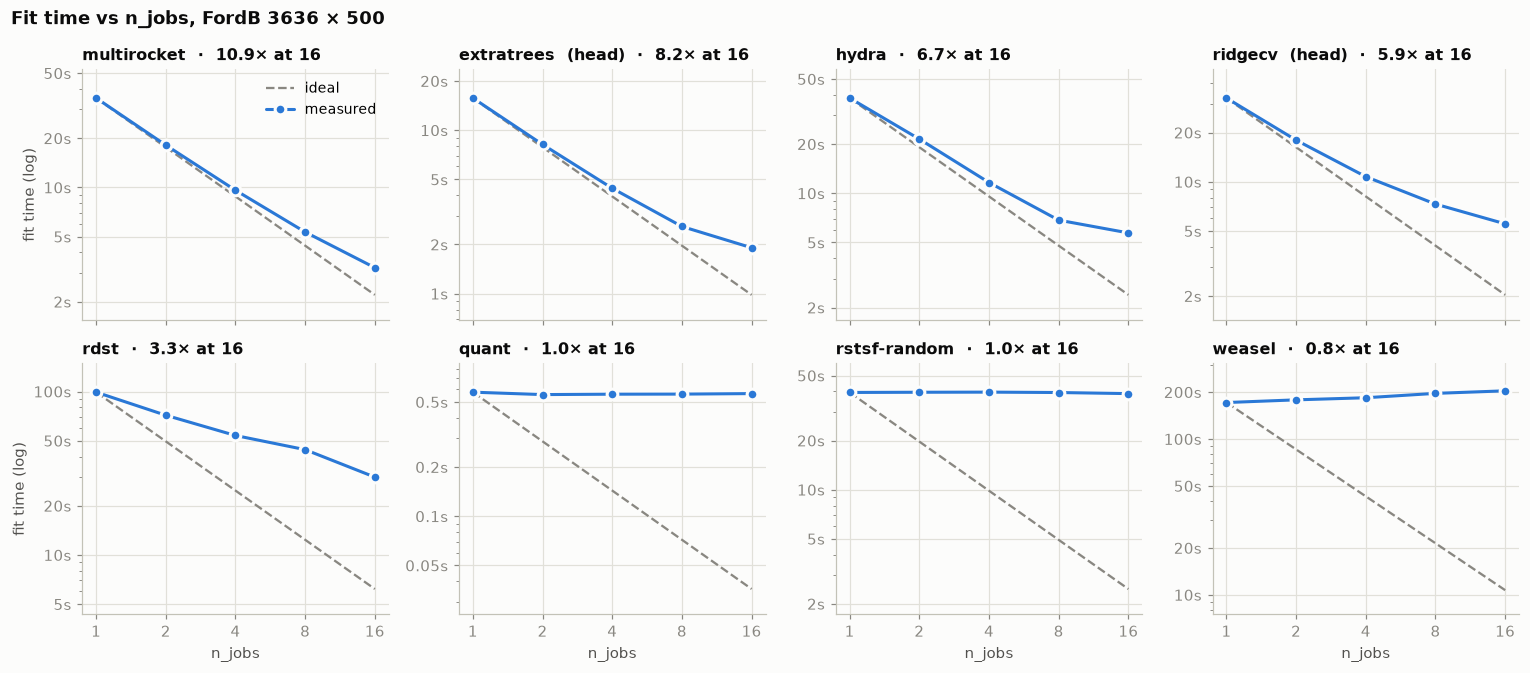

In [6]:
# Fit time per model vs ideal linear scaling

ncols = 4
nrows = int(np.ceil(len(order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.1 * nrows), sharex=True)
for ax, name in zip(axes.flat, order[::-1]):
    d = results[results["what"] == name].sort_values("n_jobs")
    t1 = d["seconds"].iloc[0]
    ax.plot(GRID, [t1 / g for g in GRID], ls="--", lw=1.5, color=MUTED, label="ideal")
    ax.plot(d["n_jobs"], d["seconds"], lw=2, color=SERIES, marker="o", ms=7,
            mec=SURFACE, mew=2, solid_capstyle="round", label="measured")
    s16 = d["speed-up"].iloc[-1]
    ax.set_title(f"{label[name]}  ·  {s16:.1f}× at {max(GRID)}", loc="left", fontsize=10.5)
    ax.set_xscale("log", base=2)
    ax.set_xticks(GRID, [str(g) for g in GRID])
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}s"))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_ylim(min(d["seconds"].min(), t1 / max(GRID)) * 0.7, d["seconds"].max() * 1.5)
for ax in axes[-1]:
    ax.set_xlabel("n_jobs")
for ax in axes[:, 0]:
    ax.set_ylabel("fit time (log)")
for ax in axes.flat[len(order):]:
    ax.set_visible(False)
axes.flat[0].legend(loc="upper right", fontsize=9)
fig.suptitle(f"Fit time vs n_jobs, {DATASET} {X.shape[0]} × {X.shape[-1]}", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

In [7]:
results.pivot(index="n_jobs", columns="what", values=["seconds", "speed-up"]).round(2)

seconds                                                       \
what   extratrees  hydra multirocket quant   rdst ridgecv rstsf-random   
n_jobs                                                                   
1           15.73  38.26       35.23  0.57  99.13   32.53        39.41   
2            8.18  21.46       18.15  0.55  71.61   17.98        39.52   
4            4.41  11.64        9.61  0.56  53.84   10.75        39.59   
8            2.58   6.85        5.34  0.56  44.11    7.30        39.38   
16           1.91   5.72        3.23  0.56  29.96    5.53        38.78   

                 speed-up                                                     \
what    weasel extratrees hydra multirocket quant  rdst ridgecv rstsf-random   
n_jobs                                                                         
1       171.44       1.00  1.00        1.00  1.00  1.00    1.00         1.00   
2       178.38       1.92  1.78        1.94  1.03  1.38    1.81         1.00   
4       184.03       3.57  3.29        3.67  1.03  1.84    3.03         1.00   
8       196.30       6.11  5.59        6.60  1.03  2.25    4.45         1.00   
16      203.84       8.24  6.69       10.91  1.02  3.31    5.88         1.02   

               
what   weasel  
n_jobs         
1        1.00  
2        0.96  
4        0.93  
8        0.87  
16       0.84